# 策略相关性分析器（通用版）

这份 notebook 用于**直接读取各策略已导出的回测结果文件夹**，计算多策略之间的：

- 共存区间净值与收益率
- 日 / 周 / 月收益相关性
- 相关性热力图
- 滚动相关性
- 多策略净值对比
- 固定权重组合效果（可选）

## 设计目标

- **不重跑回测**
- 只依赖各策略导出的 `nav.csv`（必要）和 `summary.csv`（可选）
- 通过手动指定：

```python
STRATEGY_EXPORTS = {
    "RP": "data/exports_risk_parity",
    "DM": "data/exports_dual_momentum",
}
```

来兼容后续更多策略

## 当前已兼容的导出格式

基于你现有的 RP / DM 回测 notebook，这份分析器默认支持：

- `nav.csv`
- `summary.csv`（可选）
- `weights.csv`（本 notebook 不强依赖）

其中 `nav.csv` 至少需要能识别出：

- 日期列（如 `trade_date`，或导出后的索引列）
- 净值列（优先识别 `nav`，也兼容常见其他名字）

---


In [37]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

print("ready")


ready


In [38]:
# ========= 手动指定策略名与回测结果文件夹 =========

STRATEGY_EXPORTS = {
    "RP": "data/exports_risk_parity",
    "DM": "data/exports_dual_momentum",
    # "CTA": "data/exports_cta",
    # "Alpha": "data/exports_alpha",
}

# 是否只保留所有策略都共存的日期
USE_COMMON_PERIOD_ONLY = True

# 频率：用于滚动相关性和相关矩阵展示
ROLLING_WINDOW_DAYS = 60

# 可选：分析起止日期（留空表示自动）
ANALYSIS_START = None
ANALYSIS_END = None

# 可选：固定权重组合测试（名字必须和 STRATEGY_EXPORTS 的 key 一致）
PORTFOLIO_WEIGHTS = {
    "RP": 0.8,
    "DM": 0.2,
}


In [39]:
# ========= 工具函数：读取与标准化 =========

def _to_path(x):
    return Path(x).expanduser().resolve()

def _find_first_existing_file(folder: Path, candidates):
    for name in candidates:
        p = folder / name
        if p.exists():
            return p
    return None

def _infer_date_column(df: pd.DataFrame) -> str:
    candidates = ["trade_date", "date", "datetime", "index"]
    for c in candidates:
        if c in df.columns:
            return c

    unnamed = [c for c in df.columns if str(c).startswith("Unnamed")]
    if len(unnamed) > 0:
        return unnamed[0]

    # 如果第一列看起来像日期，也接受
    first_col = df.columns[0]
    sample = pd.to_datetime(df[first_col], errors="coerce")
    if sample.notna().mean() > 0.7:
        return first_col

    raise ValueError("无法识别日期列，请检查 nav.csv 的格式。")

def _infer_nav_column(df: pd.DataFrame) -> str:
    candidates = [
        "nav", "portfolio_value", "equity", "net_value",
        "strategy_nav", "account_value"
    ]
    for c in candidates:
        if c in df.columns:
            return c

    # 常见情形：除日期列外只剩一个数值列
    non_date_cols = [c for c in df.columns if c not in {"trade_date", "date", "datetime", "index"} and not str(c).startswith("Unnamed")]
    numeric_cols = [c for c in non_date_cols if pd.api.types.is_numeric_dtype(df[c])]
    if len(numeric_cols) == 1:
        return numeric_cols[0]

    raise ValueError("无法识别净值列，请检查 nav.csv 的格式。")

def load_single_strategy_export(strategy_name: str, export_dir: str | Path) -> dict:
    folder = _to_path(export_dir)
    if not folder.exists():
        raise FileNotFoundError(f"[{strategy_name}] 导出目录不存在: {folder}")

    nav_path = _find_first_existing_file(folder, ["nav.csv", "nav.parquet", "nav.pkl"])
    if nav_path is None:
        raise FileNotFoundError(f"[{strategy_name}] 未找到 nav 文件（支持 nav.csv / nav.parquet / nav.pkl）")

    if nav_path.suffix.lower() == ".csv":
        nav_raw = pd.read_csv(nav_path)
    elif nav_path.suffix.lower() == ".parquet":
        nav_raw = pd.read_parquet(nav_path)
    elif nav_path.suffix.lower() == ".pkl":
        nav_raw = pd.read_pickle(nav_path)
    else:
        raise ValueError(f"[{strategy_name}] 不支持的 nav 文件类型: {nav_path.suffix}")

    date_col = _infer_date_column(nav_raw)
    nav_col = _infer_nav_column(nav_raw)

    nav_df = nav_raw.copy()
    nav_df[date_col] = pd.to_datetime(nav_df[date_col], errors="coerce")
    nav_df = nav_df.dropna(subset=[date_col]).sort_values(date_col)
    nav_df = nav_df[[date_col, nav_col]].rename(columns={date_col: "trade_date", nav_col: "nav"})
    nav_df["nav"] = pd.to_numeric(nav_df["nav"], errors="coerce")
    nav_df = nav_df.dropna(subset=["nav"]).drop_duplicates(subset=["trade_date"], keep="last")
    nav_df = nav_df.set_index("trade_date").sort_index()

    # 统一转成从 1 开始的标准化净值，便于比较
    std_nav = nav_df["nav"].astype(float).copy()
    first_valid = std_nav.dropna().iloc[0]
    std_nav = std_nav / first_valid

    ret = std_nav.pct_change().replace([np.inf, -np.inf], np.nan)

    summary_path = folder / "summary.csv"
    summary_df = None
    if summary_path.exists():
        try:
            tmp = pd.read_csv(summary_path)
            if tmp.shape[1] >= 2:
                if "Unnamed: 0" in tmp.columns:
                    tmp = tmp.rename(columns={"Unnamed: 0": "metric"})
                elif tmp.columns[0] != "metric":
                    tmp = tmp.rename(columns={tmp.columns[0]: "metric"})
                if tmp.columns[1] != "value":
                    tmp = tmp.rename(columns={tmp.columns[1]: "value"})
                summary_df = tmp[["metric", "value"]].copy()
        except Exception as e:
            print(f"[{strategy_name}] summary.csv 读取失败，已跳过：{e}")

    return {
        "strategy_name": strategy_name,
        "export_dir": folder,
        "nav_path": nav_path,
        "nav_df": nav_df,
        "nav": std_nav.rename(strategy_name),
        "returns": ret.rename(strategy_name),
        "summary_df": summary_df,
    }

def load_all_strategies(strategy_exports: dict[str, str | Path]) -> dict[str, dict]:
    loaded = {}
    for name, folder in strategy_exports.items():
        loaded[name] = load_single_strategy_export(name, folder)
    return loaded

def apply_date_filter(df: pd.DataFrame, start=None, end=None) -> pd.DataFrame:
    out = df.copy()
    if start is not None:
        out = out.loc[pd.Timestamp(start):]
    if end is not None:
        out = out.loc[:pd.Timestamp(end)]
    return out


In [40]:
# ========= 读取全部策略结果 =========

strategy_data = load_all_strategies(STRATEGY_EXPORTS)

print("已加载策略：", list(strategy_data.keys()))
for name, obj in strategy_data.items():
    nav = obj["nav"]
    print(
        f"{name}: rows={len(nav):4d}, "
        f"start={nav.index.min().date()}, "
        f"end={nav.index.max().date()}, "
        f"file={obj['nav_path']}"
    )


已加载策略： ['RP', 'DM']
RP: rows= 780, start=2023-01-03, end=2026-03-26, file=D:\codeWork\RiskParity\data\exports_risk_parity\nav.csv
DM: rows=1508, start=2020-01-02, end=2026-03-26, file=D:\codeWork\RiskParity\data\exports_dual_momentum\nav.csv


In [41]:
# ========= 构建净值矩阵 / 收益矩阵，并按共同区间对齐 =========

nav_matrix = pd.concat([v["nav"] for v in strategy_data.values()], axis=1).sort_index()
ret_matrix = pd.concat([v["returns"] for v in strategy_data.values()], axis=1).sort_index()

nav_matrix = apply_date_filter(nav_matrix, ANALYSIS_START, ANALYSIS_END)
ret_matrix = apply_date_filter(ret_matrix, ANALYSIS_START, ANALYSIS_END)

if USE_COMMON_PERIOD_ONLY:
    nav_common = nav_matrix.dropna(how="any").copy()
    ret_common = nav_common.pct_change().dropna(how="any")
else:
    nav_common = nav_matrix.copy()
    ret_common = ret_matrix.copy()

print("净值矩阵 shape =", nav_matrix.shape)
print("共存区间净值矩阵 shape =", nav_common.shape)
if len(nav_common) > 0:
    nav_common_rebased = nav_common / nav_common.iloc[0]
    print("共存区间：", nav_common.index.min().date(), "->", nav_common.index.max().date())
else:
    nav_common_rebased = nav_common.copy()
    print("共存区间为空，请检查策略文件夹和日期过滤。")
ret_common = nav_common_rebased.pct_change().dropna(how="any")
display(nav_common.tail())
display(ret_common.tail())


净值矩阵 shape = (1508, 2)
共存区间净值矩阵 shape = (780, 2)
共存区间： 2023-01-03 -> 2026-03-26


,RP,DM
trade_date,,
2026-03-20,1.271932,1.978488
2026-03-23,1.277189,2.047840
2026-03-24,1.282277,2.056575
2026-03-25,1.266210,1.954864
2026-03-26,1.272863,1.989545


,RP,DM
trade_date,,
2026-03-20,-0.006390,0.012903
2026-03-23,0.004133,0.035053
2026-03-24,0.003984,0.004265
2026-03-25,-0.012530,-0.049456
2026-03-26,0.005254,0.017741


In [42]:
# ========= 各策略基础画像（基于共存区间） =========

def calc_drawdown(nav: pd.Series) -> pd.Series:
    nav = nav.astype(float)
    running_max = nav.cummax()
    return nav / running_max - 1.0

def summarize_nav(nav: pd.Series, annualization: int = 252, risk_free_rate: float = 0.0) -> pd.Series:
    nav = nav.dropna().astype(float)
    ret = nav.pct_change().dropna()
    if len(nav) < 2 or len(ret) == 0:
        return pd.Series(dtype=float)

    total_return = nav.iloc[-1] / nav.iloc[0] - 1.0
    n = len(ret)
    annual_return = (nav.iloc[-1] / nav.iloc[0]) ** (annualization / n) - 1.0
    annual_volatility = ret.std(ddof=1) * np.sqrt(annualization)
    excess_return = annual_return - risk_free_rate
    sharpe_ratio = np.nan if np.isclose(annual_volatility, 0.0) else excess_return / annual_volatility
    dd = calc_drawdown(nav)
    max_drawdown = dd.min()
    calmar_ratio = np.nan if np.isclose(max_drawdown, 0.0) else annual_return / abs(max_drawdown)

    return pd.Series({
        "total_return": total_return,
        "annual_return": annual_return,
        "annual_volatility": annual_volatility,
        "sharpe_ratio": sharpe_ratio,
        "max_drawdown": max_drawdown,
        "calmar_ratio": calmar_ratio,
        "start": nav.index.min(),
        "end": nav.index.max(),
        "rows": len(nav),
    })

summary_common = pd.concat(
    {col: summarize_nav(nav_common[col]) for col in nav_common.columns},
    axis=1
).T

display(summary_common)


,total_return,annual_return,annual_volatility,sharpe_ratio,max_drawdown,calmar_ratio,start,end,rows
RP,0.272863,0.081175,0.067915,1.195242,-0.058754,1.381617,2023-01-03 00:00:00,2026-03-26 00:00:00,780
DM,0.369386,0.107044,0.118981,0.899673,-0.102038,1.049061,2023-01-03 00:00:00,2026-03-26 00:00:00,780


In [43]:
# ========= 日 / 周 / 月收益相关性矩阵 =========

daily_corr = ret_common.corr()

weekly_nav = nav_common.resample("W-FRI").last().dropna(how="all")
weekly_ret = weekly_nav.pct_change().dropna(how="all")
weekly_corr = weekly_ret.corr()

monthly_nav = nav_common.resample("ME").last().dropna(how="all")
monthly_ret = monthly_nav.pct_change().dropna(how="all")
monthly_corr = monthly_ret.corr()

print("日收益相关矩阵：")
display(daily_corr)

print("周收益相关矩阵：")
display(weekly_corr)

print("月收益相关矩阵：")
display(monthly_corr)


日收益相关矩阵：


,RP,DM
RP,1.000000,0.595439
DM,0.595439,1.000000


周收益相关矩阵：


,RP,DM
RP,1.000000,0.493993
DM,0.493993,1.000000


月收益相关矩阵：


,RP,DM
RP,1.000000,0.606187
DM,0.606187,1.000000


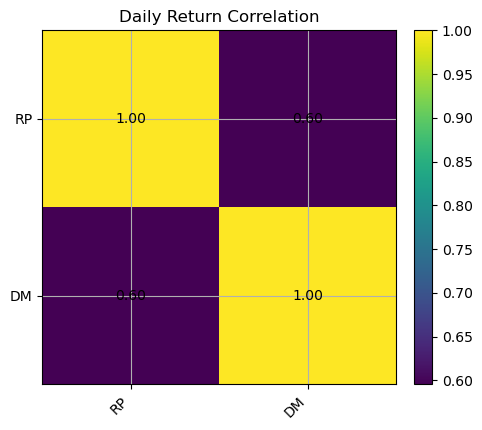

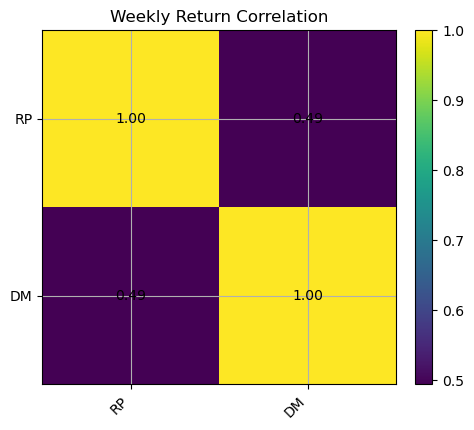

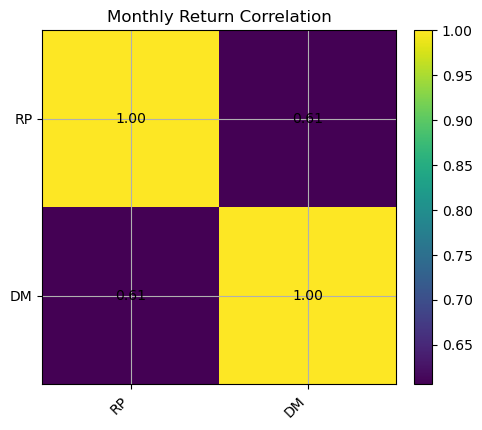

In [44]:
# ========= 相关性热力图 =========

def plot_corr_heatmap(corr_df: pd.DataFrame, title: str):
    if corr_df.empty:
        print(title, "为空")
        return

    arr = corr_df.values
    fig, ax = plt.subplots(figsize=(1.6 * len(corr_df.columns) + 2, 1.2 * len(corr_df.index) + 2))
    im = ax.imshow(arr)

    ax.set_xticks(range(len(corr_df.columns)))
    ax.set_xticklabels(corr_df.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr_df.index)))
    ax.set_yticklabels(corr_df.index)
    ax.set_title(title)

    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            val = arr[i, j]
            text = "" if pd.isna(val) else f"{val:.2f}"
            ax.text(j, i, text, ha="center", va="center")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

plot_corr_heatmap(daily_corr, "Daily Return Correlation")
plot_corr_heatmap(weekly_corr, "Weekly Return Correlation")
plot_corr_heatmap(monthly_corr, "Monthly Return Correlation")


可用策略对： [('RP', 'DM')]


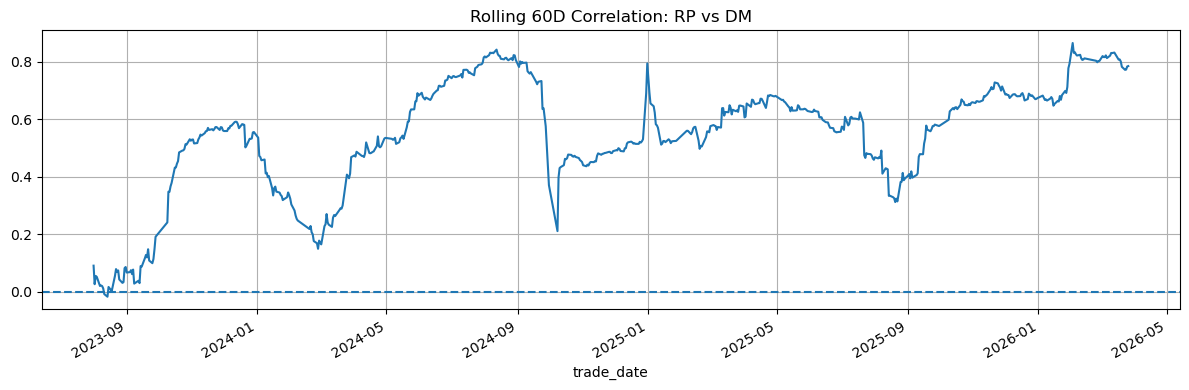

In [45]:
# ========= 滚动相关性（默认展示前两个策略；可自行改 pairs） =========

all_names = list(nav_common.columns)
pairs = []
if len(all_names) >= 2:
    for i in range(len(all_names)):
        for j in range(i + 1, len(all_names)):
            pairs.append((all_names[i], all_names[j]))

print("可用策略对：", pairs)

if len(pairs) == 0:
    print("策略数量不足 2，无法计算滚动相关性。")
else:
    fig, axes = plt.subplots(len(pairs), 1, figsize=(12, max(4, 3 * len(pairs))), sharex=True)
    if len(pairs) == 1:
        axes = [axes]

    for ax, (a, b) in zip(axes, pairs):
        roll_corr = ret_common[a].rolling(ROLLING_WINDOW_DAYS).corr(ret_common[b])
        roll_corr.plot(ax=ax)
        ax.set_title(f"Rolling {ROLLING_WINDOW_DAYS}D Correlation: {a} vs {b}")
        ax.axhline(0.0, linestyle="--")

    plt.tight_layout()
    plt.show()


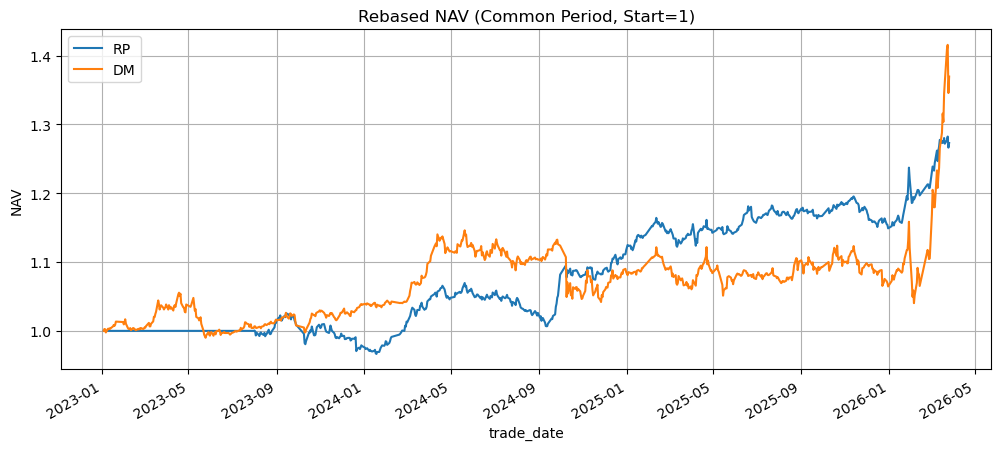

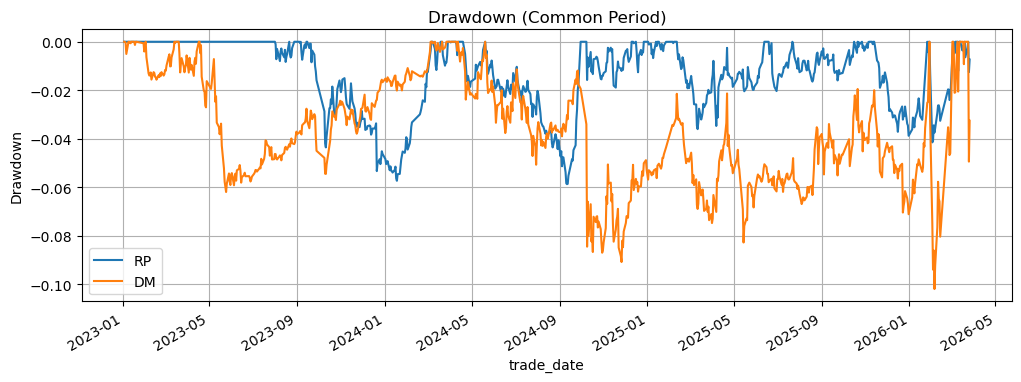

In [46]:
# ========= 多策略净值对比 =========

if len(nav_common_rebased) > 0:
    ax = nav_common_rebased.plot(figsize=(12, 5), title="Rebased NAV (Common Period, Start=1)")
    ax.set_ylabel("NAV")
    plt.show()

    dd_df = pd.concat({c: calc_drawdown(nav_common_rebased[c]) for c in nav_common_rebased.columns}, axis=1)
    ax = dd_df.plot(figsize=(12, 4), title="Drawdown (Common Period)")
    ax.set_ylabel("Drawdown")
    plt.show()
else:
    print("共存净值为空，无法作图。")


组合权重：


,weight
RP,0.8
DM,0.2


统一口径表现（当前分析区间 / 共存区间，起点重映射为 1）：


strategy,RP,DM,COMBO
total_return,0.272863,0.369386,0.294518
annual_return,0.081175,0.107044,0.087208
annual_volatility,0.067915,0.118981,0.071164
sharpe_ratio,1.195242,0.899673,1.225444
max_drawdown,-0.058754,-0.102038,-0.053441
calmar_ratio,1.381617,1.049061,1.631844
start,2023-01-03 00:00:00,2023-01-03 00:00:00,2023-01-04 00:00:00
end,2026-03-26 00:00:00,2026-03-26 00:00:00,2026-03-26 00:00:00
rows,780,780,779


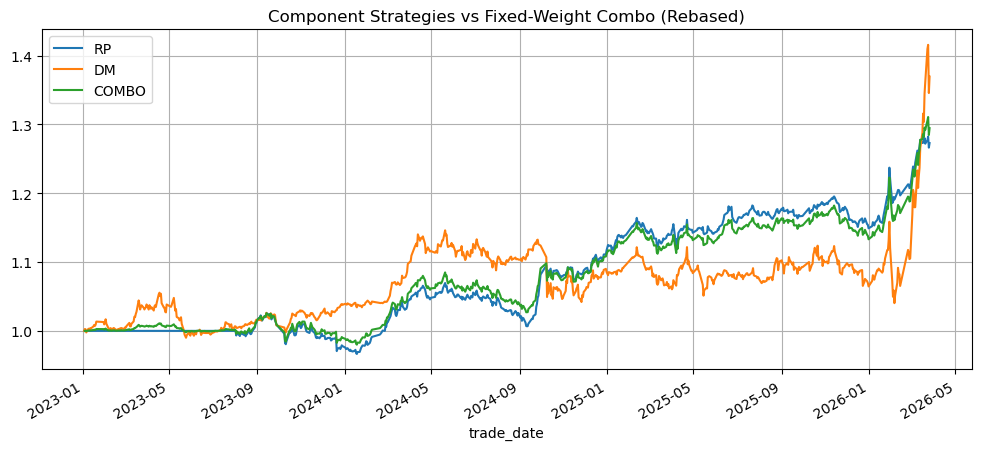

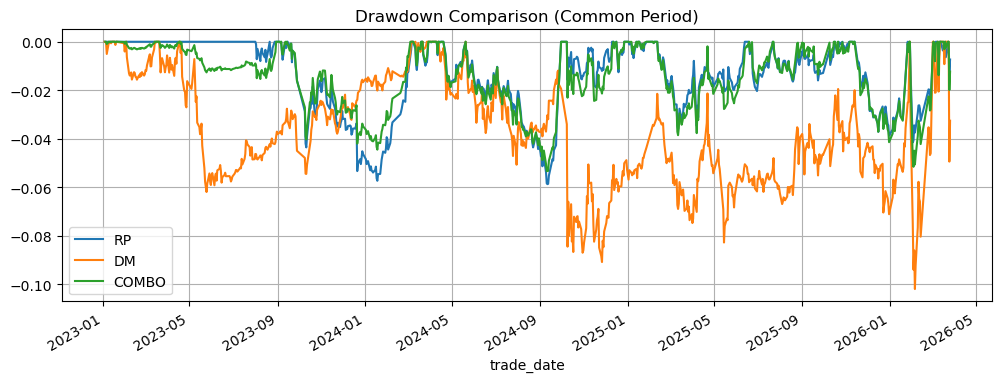

In [50]:
# ========= 固定权重组合测试（可选） + 统一口径表现展示 =========

def normalize_weight_dict(weight_dict: dict) -> dict:
    s = sum(float(v) for v in weight_dict.values())
    if np.isclose(s, 0.0):
        raise ValueError("PORTFOLIO_WEIGHTS 的和不能为 0")
    return {k: float(v) / s for k, v in weight_dict.items()}

if len(PORTFOLIO_WEIGHTS) == 0:
    print("PORTFOLIO_WEIGHTS 为空，跳过组合测试。")
else:
    weights = normalize_weight_dict(PORTFOLIO_WEIGHTS)
    missing = [k for k in weights if k not in ret_common.columns]
    if len(missing) > 0:
        raise ValueError(f"PORTFOLIO_WEIGHTS 中这些策略未加载成功或不在共存矩阵中: {missing}")

    sub_ret = ret_common[list(weights.keys())].copy()
    w = pd.Series(weights).reindex(sub_ret.columns)

    combo_ret = sub_ret.mul(w, axis=1).sum(axis=1)
    combo_nav = (1.0 + combo_ret).cumprod()
    combo_nav.iloc[0] = 1.0

    combo_summary = summarize_nav(combo_nav)

    print("组合权重：")
    display(w.to_frame("weight"))

    # ===== 统一口径表现：组件策略 + 组合 =====
    unified_summary = pd.concat(
        {name: summarize_nav(nav_common_rebased[name]) for name in w.index},
        axis=1
    ).T

    unified_summary.loc["COMBO"] = combo_summary
    unified_summary.index.name = "strategy"

    print("统一口径表现（当前分析区间 / 共存区间，起点重映射为 1）：")
    display(unified_summary.T)

    # ===== 净值对比 =====
    compare_nav = nav_common_rebased[list(weights.keys())].copy()
    compare_nav["COMBO"] = combo_nav
    compare_nav.plot(figsize=(12, 5), title="Component Strategies vs Fixed-Weight Combo (Rebased)")
    plt.show()

    # ===== 回撤对比 =====
    compare_dd = pd.concat(
        {name: calc_drawdown(compare_nav[name]) for name in compare_nav.columns},
        axis=1
    )
    compare_dd.plot(figsize=(12, 4), title="Drawdown Comparison (Common Period)")
    plt.show()

In [48]:
# ========= 可选：查看各策略原始 summary.csv =========

for name, obj in strategy_data.items():
    print(f"\n===== {name} | {obj['export_dir']} =====")
    if obj["summary_df"] is None:
        print("未找到或未成功读取 summary.csv")
    else:
        display(obj["summary_df"])



===== RP | D:\codeWork\RiskParity\data\exports_risk_parity =====


,metric,value
0,total_return,0.272863
1,annual_return,0.081175
2,excess_return,0.081175
3,annual_volatility,0.067872
4,sharpe_ratio,1.182548
5,max_drawdown,-0.058754
6,calmar_ratio,-1.381617
7,avg_asset_correlation,0.075804



===== DM | D:\codeWork\RiskParity\data\exports_dual_momentum =====


,metric,value
0,total_return,0.989545
1,annual_return,0.121909
2,excess_return,0.121909
3,annual_volatility,0.107434
4,sharpe_ratio,1.123891
5,max_drawdown,-0.102038
6,calmar_ratio,1.194737
